In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import protfasta
import os
#os.chdir("..")

# Loading in activities, yeast TF tiles, and sanborn annotations

Yeast TFs are from # Names of yeast TFs from StallerLabShared/LabDocs/proteinSequences/TFs_Yeast/SGDresources/yeast_TFs_MitraLab

Focusing on t = 30 minutes Z-scored results

In [2]:
chopTFs_design = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/ChopYeastTFsDesign.csv", index_col = 0)
chopTFs_design["id"] = chopTFs_design["Name"].str.split("|").str[1].str.split("_").str[0]
chopTFs_design["tile_start"] = chopTFs_design["Name"].str.split("|").str[1].str.split("_").str[1]
chopTFs_design = chopTFs_design.dropna()
chopTFs_design["tile_start"] = chopTFs_design["tile_start"].astype(int)
chopTFs_design["tile_end"] = chopTFs_design["tile_start"] + 40
chopTFs_design = chopTFs_design.rename(columns = {"ADseq" : "seq"})
chopTFs_design = chopTFs_design.drop(columns = ["ArrayDNA", "Name"])
chopTFs_design

,seq,id,tile_start,tile_end
0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,YAL051W,1,41
1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,YAL051W,6,46
2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,YAL051W,11,51
3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,YAL051W,16,56
4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,YAL051W,21,61
...,...,...,...,...
18413,KLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDL,YPR196W,411,451
18414,NILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRP,YPR196W,416,456
18415,VSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLND,YPR196W,421,461
18416,FSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLNDDSKDE,YPR196W,426,466


In [3]:
yeast_TF_lens = pd.DataFrame(chopTFs_design.groupby("id")["tile_start"].max()).reset_index().rename(columns = {"tile_start" : "last_start"})
yeast_TF_lens

,id,last_start
0,YAL051W,1007
1,YAR007C,581
2,YBL021C,104
3,YBL022C,1093
4,YBL054W,485
...,...,...
156,YPR022C,1093
157,YPR052C,53
158,YPR065W,328
159,YPR104C,896


In [4]:
chopTFs_design = pd.merge(chopTFs_design, yeast_TF_lens)
chopTFs_design

,seq,id,tile_start,tile_end,last_start
0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,YAL051W,1,41,1007
1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,YAL051W,6,46,1007
2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,YAL051W,11,51,1007
3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,YAL051W,16,56,1007
4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,YAL051W,21,61,1007
...,...,...,...,...,...
18412,KLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDL,YPR196W,411,451,430
18413,NILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRP,YPR196W,416,456,430
18414,VSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLND,YPR196W,421,461,430
18415,FSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLNDDSKDE,YPR196W,426,466,430


In [12]:
AD_speeds = pd.read_csv("../../../output/ChopTFs_pipeline/speed/exponential_fit.csv", index_col = 0)
AD_speeds = AD_speeds.rename(columns = {"k" : "speed", "ADseq" : "seq"})
# AD_activities = AD_activities[AD_activities["time"] == 30]
# AD_activities["error"] = AD_activities["ci_hi"] - AD_activities["ci_low"]
AD_speeds = AD_speeds[["seq", "speed"]]
AD_speeds

,seq,speed
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.269285
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,0.132274
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,0.128593
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,0.096377
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,0.117486
...,...,...
852,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,0.093508
853,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,0.080102
854,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,0.111316
855,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,0.084823


In [13]:
# AD_activities_confident = AD_activities[AD_activities["error"] < AD_activities["speed"] * 2]
# AD_activities_confident

In [36]:
merged_speeds = AD_speeds.merge(
    chopTFs_design,
    on="seq"
)
merged_speeds["tile_center"] = merged_speeds["tile_start"] + 19
merged_speeds

,seq,speed,id,tile_start,tile_end,last_start,tile_center
0,AAKRSGAKTIIFPKDNLNDWEELPDNVKEGLEPLAADWYN,0.269285,YBL022C,1061,1101,1093,1080
1,AASNSYAIPENELLDEDTMNFISSLKNDLSNISNSLPFEY,0.132274,YNL216W,626,666,787,645
2,AAVPQQNIAPPFLNTNSSATDSNPNTNLEDSLFFDHDLLS,0.128593,YDL106C,426,466,519,445
3,AELHNWEPPLYDSVGNHNHAGTMESHPHTNIHEELKEFLS,0.096377,YBL103C,416,456,446,435
4,AELPRRFMDLESWRIETYNELERWFQVDVPKNFEMMNCKF,0.117486,YLR014C,581,621,864,600
...,...,...,...,...,...,...,...
795,YNFQNARLLIRKIWQNEADGISEHDLVHMIDELDYNINFA,0.093508,YDL170W,488,528,488,507
796,YPQDLVSSPAMSHLTANNDDFDDLLSVASMNSNYLLPVNS,0.080102,YNL027W,206,246,638,225
797,YSLVTGKQPLIPHEMTSCLFPKDVVGLGVDDSMDCFTLIN,0.111316,YER184C,386,426,754,405
798,YSNARGSDPSSYAIEGEYKTLATDDLGNILNLNYGETNEV,0.084823,YDR146C,26,66,669,45


In [28]:
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import pearsonr

WINDOW = 40  # your tile size


# ------------------------------------------------------------
# 1. FIXED TILE EXPANSION (for overlap method)
# ------------------------------------------------------------
def build_overlap_profile(df):
    results = []

    for pid, g in df.groupby("id"):
        pos_vals = defaultdict(list)

        for _, r in g.iterrows():
            start = int(r["tile_start"])
            end = start + WINDOW - 1  # IMPORTANT FIX

            for p in range(start, end + 1):
                pos_vals[p].append(r["speed"])

        positions = np.array(sorted(pos_vals.keys()))
        values = np.array([np.mean(pos_vals[p]) for p in positions])

        results.append(pd.DataFrame({
            "id": pid,
            "position": positions,
            "speed_overlap": values
        }))

    return pd.concat(results, ignore_index=True)


# ------------------------------------------------------------
# 2. FIXED-K LOESS (matches "20 nearest points" idea)
# ------------------------------------------------------------
def loess_per_protein(df, k=5):
    out = []

    for pid, g in df.groupby("id"):
        g = g.sort_values("tile_center")

        x = g["tile_center"].values
        y = g["speed"].values

        frac = min(1.0, k / len(g))  # fixed-k approximation

        smooth = lowess(y, x, frac=frac, it=1, return_sorted=False)

        # clamp to observed range (paper step)
        smooth = np.clip(smooth, y.min(), y.max())

        out.append(pd.DataFrame({
            "id": pid,
            "tile_center": x,
            "speed_loess": smooth
        }))

    return pd.concat(out, ignore_index=True)


# ------------------------------------------------------------
# 3. EXPAND LOESS TO POSITION SCALE
# ------------------------------------------------------------
def expand_loess_to_positions(df_loess, df_raw):
    out = []

    for pid, g in df_loess.groupby("id"):
        raw = df_raw[df_raw["id"] == pid]

        min_pos = raw["tile_start"].min()
        max_pos = (raw["tile_start"] + WINDOW - 1).max()

        positions = np.arange(min_pos, max_pos + 1)

        x = g["tile_center"].values
        y = g["speed_loess"].values

        # extend domain to full tile coverage instead of just tile centers
        f = np.full_like(positions, np.nan, dtype=float)
        valid = (positions >= min_pos) & (positions <= max_pos)
        f[valid] = np.interp(positions[valid], x, y)

        out.append(pd.DataFrame({
            "id": pid,
            "position": positions,
            "speed_loess_pos": f
        }))

    return pd.concat(out, ignore_index=True)

# ------------------------------------------------------------
# 4. COVERAGE MASK (CRITICAL for fair comparison)
# ------------------------------------------------------------
def compute_coverage(df):
    cov = Counter()

    for _, r in df.iterrows():
        start = int(r["tile_start"])
        end = start + WINDOW - 1

        for p in range(start, end + 1):
            cov[p] += 1

    return cov


# ------------------------------------------------------------
# 5. MERGE + VALID CORRELATION
# ------------------------------------------------------------
def compare_methods(df, loess_pos, overlap_pos):
    merged = loess_pos.merge(overlap_pos, on=["id", "position"])

    results = []

    for pid, g in merged.groupby("id"):
        cov = compute_coverage(df[df["id"] == pid])

        # ---------------------------
        # DEFINE SHARED VALID DOMAIN
        # ---------------------------
        valid = g["position"].map(lambda p: cov[p] >= 2)
        g = g[valid].dropna()

        if len(g) < 10:
            continue

        x = g["speed_loess_pos"].values
        y = g["speed_overlap"].values

        # normalize per protein
        x = (x - x.mean()) / (x.std() + 1e-8)
        y = (y - y.mean()) / (y.std() + 1e-8)

        r, _ = pearsonr(x, y)

        results.append((pid, r))

    return pd.DataFrame(results, columns=["id", "pearson_r"])


def filter_to_high_confidence(overlap, loess_pos, df, min_coverage=2):
    cov_rows = []
    for _, r in df.iterrows():
        start = int(r["tile_start"])
        for p in range(start, start + WINDOW):
            cov_rows.append((r["id"], p))
    
    cov_df = (pd.DataFrame(cov_rows, columns=["id", "position"])
                .groupby(["id", "position"])
                .size()
                .reset_index(name="coverage"))  # explicit name, works all pandas versions

    overlap_hc = overlap.merge(cov_df, on=["id", "position"])
    overlap_hc = overlap_hc[overlap_hc["coverage"] >= min_coverage]

    loess_hc = loess_pos.merge(cov_df, on=["id", "position"])
    loess_hc = loess_hc[loess_hc["coverage"] >= min_coverage].dropna(subset=["speed_loess_pos"])

    return overlap_hc, loess_hc
    
# ------------------------------------------------------------
# 6. ONE-CALL PIPELINE
# ------------------------------------------------------------
def run_pipeline(df):
    overlap = build_overlap_profile(df)
    loess = loess_per_protein(df, k=5)
    loess_pos = expand_loess_to_positions(loess, df)
    summary = compare_methods(df, loess_pos, overlap)

    overlap_hc, loess_hc = filter_to_high_confidence(overlap, loess_pos, df)

    return overlap_hc, loess, loess_hc, summary

In [29]:
overlap, loess, loess_pos, summary = run_pipeline(merged_speeds)

(summary["pearson_r"] > 0.8).mean()

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


0.5520833333333334

In [30]:
summary[summary["pearson_r"] < 0.8]

,id,pearson_r
2,YBL103C,-0.026689
4,YBR083W,0.331861
8,YCR065W,0.625493
14,YDR034C,0.672544
15,YDR096W,0.795500
25,YER068W,0.546755
26,YER111C,0.061724
29,YFL021W,0.732699
32,YGL013C,0.687209
33,YGL071W,0.762894


In [31]:
summary[summary["pearson_r"] > 0.8].sort_values(by = "pearson_r")

,id,pearson_r
65,YLR176C,0.801978
30,YFL031W,0.808857
19,YDR310C,0.810994
12,YDL106C,0.819320
60,YKR101W,0.825012
63,YLR098C,0.839623
23,YEL009C,0.841987
34,YGL073W,0.845634
62,YLR014C,0.852264
80,YNL216W,0.855356


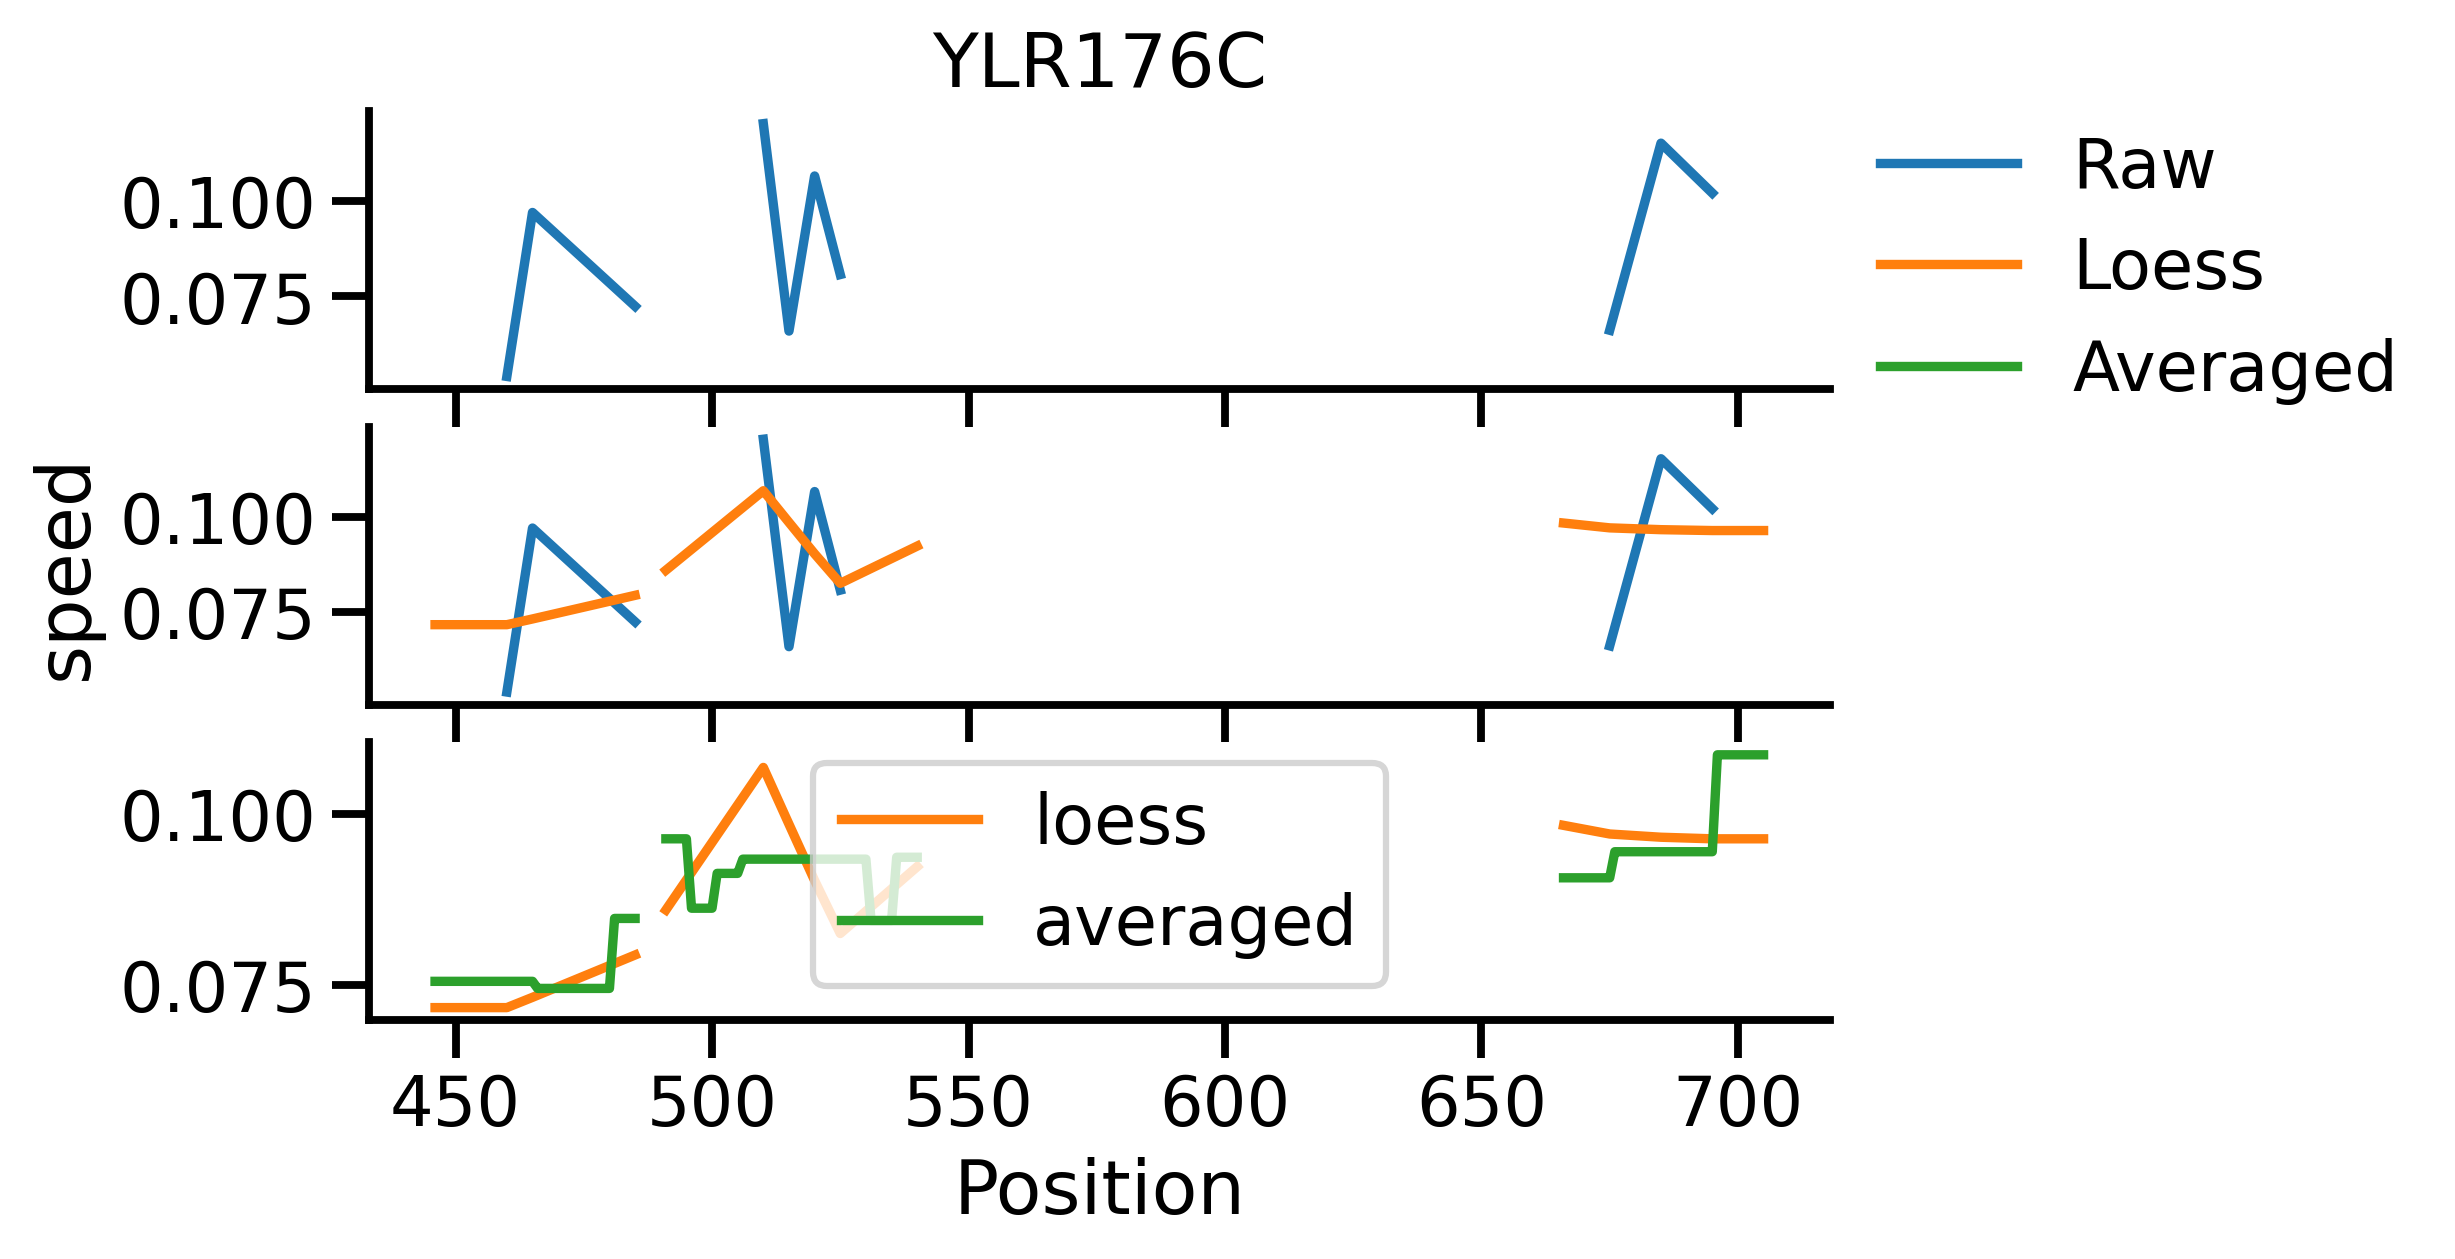

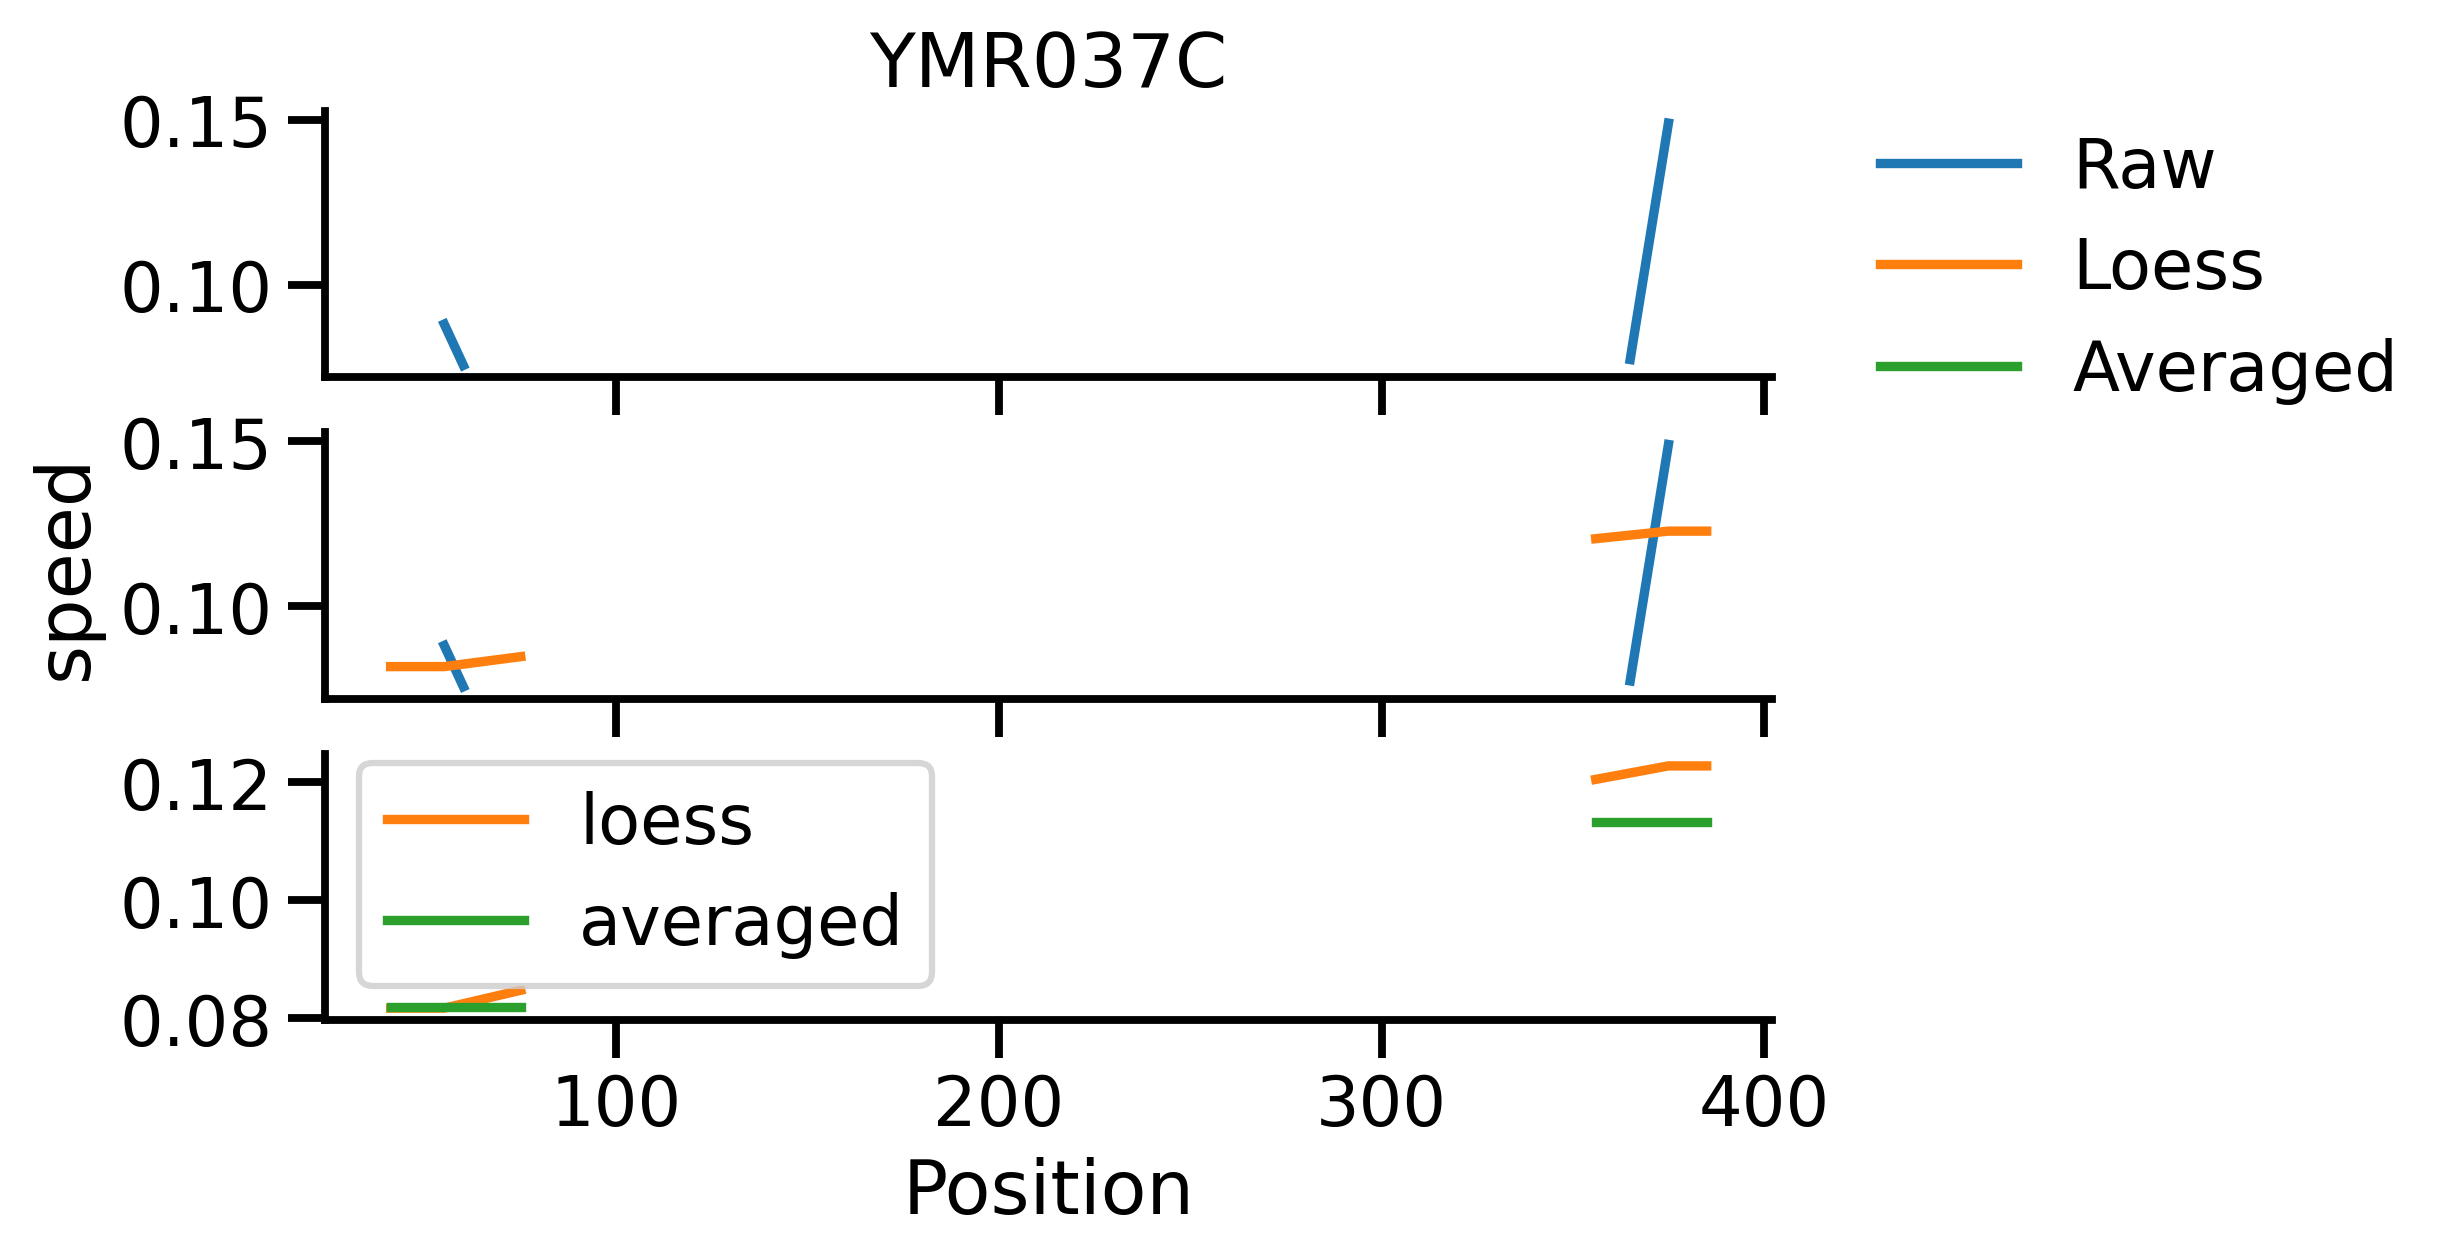

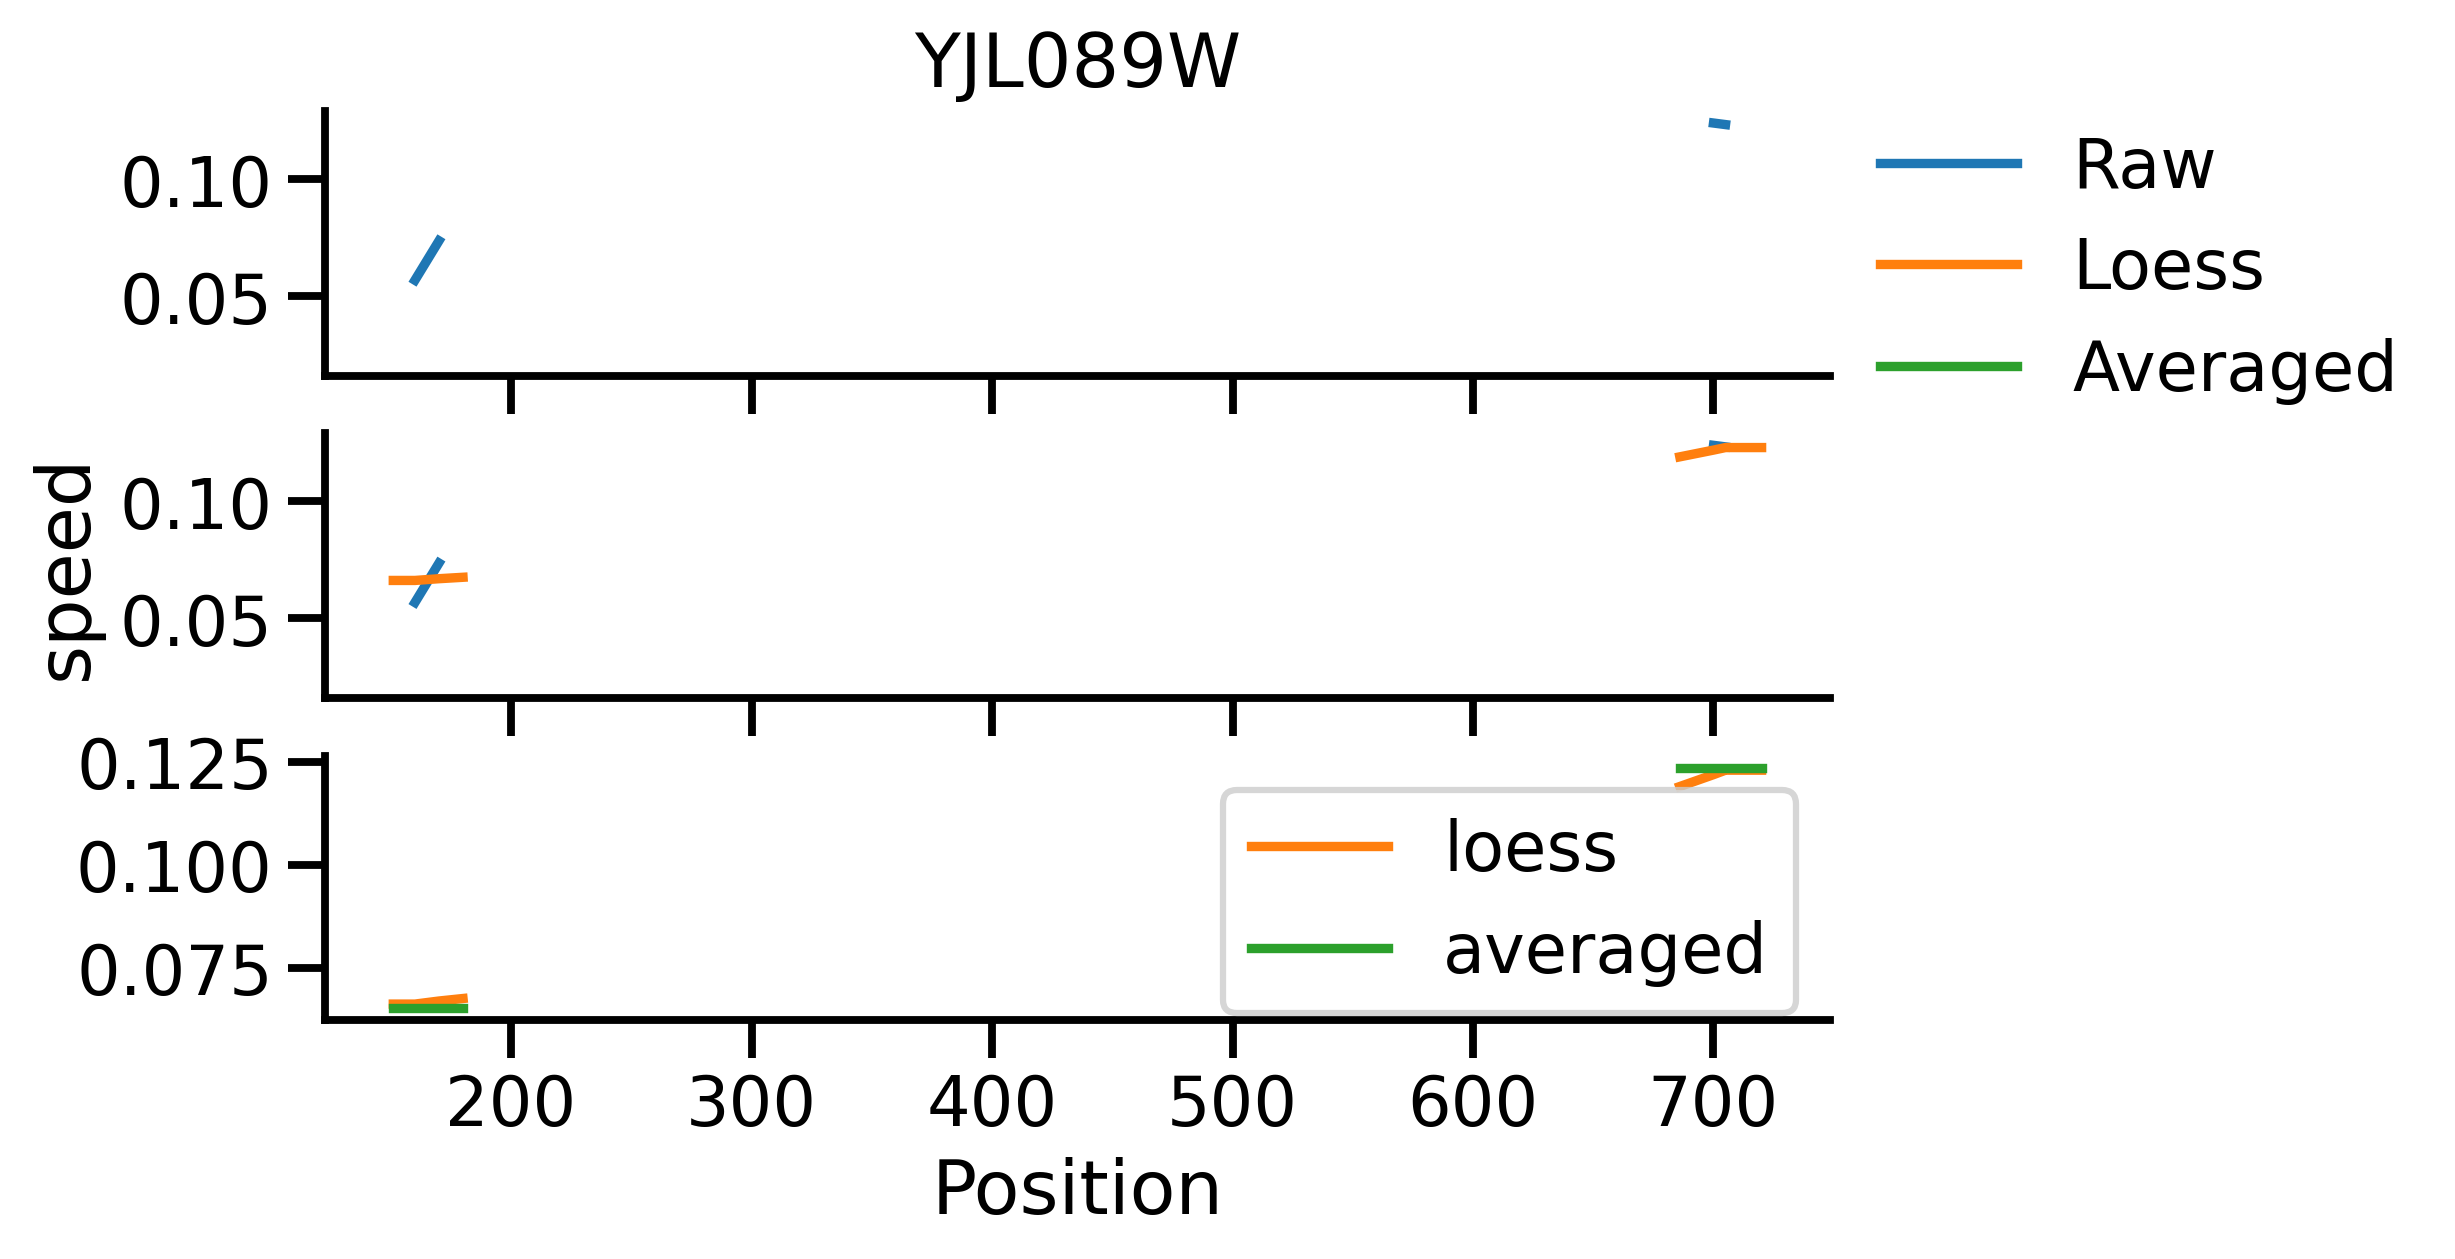

In [39]:
def split_continuous_segments(df, pos_col="position", gap=1):
    df = df.sort_values(pos_col).reset_index(drop=True)
    breaks = df[pos_col].diff() > gap
    segment_ids = breaks.cumsum()
    return [seg for _, seg in df.groupby(segment_ids)]

sns.set_context('talk')

for id in ["YLR176C", "YMR037C", "YJL089W"]:
    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True, dpi=300)

    raw_data     = merged_speeds[merged_speeds["id"] == id]
    loess_data   = loess_pos[loess_pos["id"] == id].dropna()
    overlap_data = overlap[overlap["id"] == id].dropna()

    raw_segs     = split_continuous_segments(raw_data, pos_col="tile_center", gap=20)
    loess_segs   = split_continuous_segments(loess_data)
    overlap_segs = split_continuous_segments(overlap_data)

    # --- panel 1: raw only ---
    ax = axes[0]
    for i, seg in enumerate(raw_segs):
        sns.lineplot(data=seg, x="tile_center", y="speed",
                     color="C0", label="raw" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("speed")
    ax.set_xlabel("")
    ax.set_title(id)
    ax.get_legend().remove()

    # --- panel 2: raw + loess ---
    ax = axes[1]
    for i, seg in enumerate(raw_segs):
        sns.lineplot(data=seg, x="tile_center", y="speed",
                     color="C0", label="raw" if i == 0 else "_nolegend_", ax=ax)
    for i, seg in enumerate(loess_segs):
        sns.lineplot(data=seg, x="position", y="speed_loess_pos",
                     color="C1", label="loess" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("speed")
    ax.set_xlabel("")
    ax.get_legend().remove()

    # --- panel 3: loess + averaged ---
    ax = axes[2]
    for i, seg in enumerate(loess_segs):
        sns.lineplot(data=seg, x="position", y="speed_loess_pos",
                     color="C1", label="loess" if i == 0 else "_nolegend_", ax=ax)
    for i, seg in enumerate(overlap_segs):
        sns.lineplot(data=seg, x="position", y="speed_overlap",
                     color="C2", label="averaged" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("speed")
    ax.set_xlabel("Position")
    #ax.get_legend().remove()

    # --- single figure legend ---
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color="C0", label="Raw"),
        Line2D([0], [0], color="C1", label="Loess"),
        Line2D([0], [0], color="C2", label="Averaged"),
    ]
    fig.legend(handles=legend_handles, loc="center right",
               bbox_to_anchor=(1.35, 0.8), frameon=False)

    axes[0].set_ylabel("")
    axes[2].set_ylabel("")
    
    sns.despine()
    plt.tight_layout(pad=0)
    plt.show()